## Background

AI: AI i.e Artifical Intelligence is any system that passes the turing test.

ML: It is a subset of AI and learns as well as recognizes pattern from data in which it is trained

DL: It is a subset of ML which uses artificial neural networks to learn complex patterns from large amount of data

Data Science: It combines statistics, programming, machine learning and domain knowledge to extraxt useful insights from data


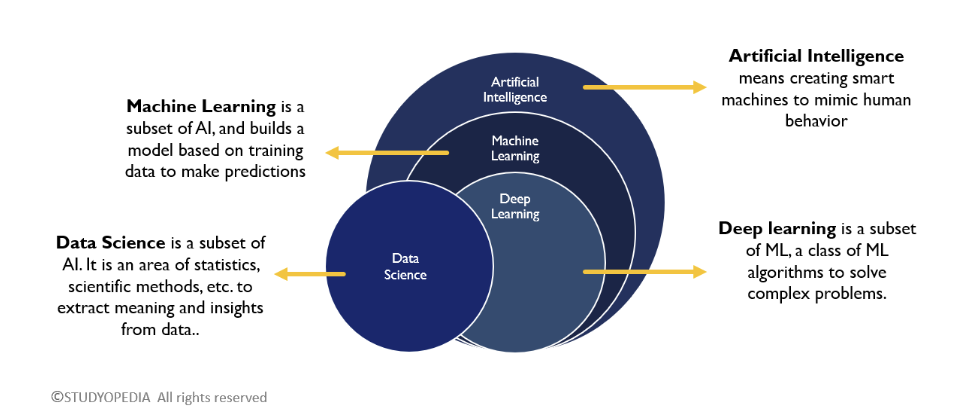

In [2]:
# dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets

# Task 1: Logistic Regression with a Single Feature

Logistic regression is used for classification problems(especially binary) making it a supervied ML algorithm

## 1) Data retrieval and collection

data is loaded using pandas from a csv file and analyzed

In [ ]:
#load the heart disease dataset
data=pd.read_csv("Heart_Disease_Prediction.csv")
data.head() #checking if data was loaded 


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [12]:
#shape of dataset
print("Shape of dataset:",data.shape)

#column names
print("Columns:\n", data.columns.tolist())


Shape of dataset: (270, 14)
Columns:
 ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


(270,14) means that the dataset has 270 rows and 14 columns

In [ ]:
#description of dataset
data.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


## 2) Data cleaning

we look for any missing values and anamolies and fix them

In [14]:
print(data.isnull().sum())

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


no missing values for any columns

In [ ]:
#handle missing or invalid cholestrol values

#There are no missing values in cholestrol so no changes required.

(data["Cholesterol"]<=0).sum()

np.int64(0)

having cholestrol 0 or less than 0 is medically invalid. so we checked for those values which came out to be 0. So, to conclude, there are no invalid data.

In [ ]:
#ensure the target variable is binary
print(data["Heart Disease"].unique())

<StringArray>
['Presence', 'Absence']
Length: 2, dtype: str


the data type in Heart Disease is string containing 'Presence' and 'Absence' which is not binary. so we use 'map' function to convert them into 0 and 1 where 0 is Absence and 1 is Presence

In [19]:
data["Heart Disease"] = data["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})

In [20]:
print(data["Heart Disease"].unique())

[1 0]


now the data in Heart Disease is in binary


In [21]:
#verify data types
print(data.dtypes)

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease                int64
dtype: object


## 3) Feature Design

we select, transform and prepare the data for machine learning

In [26]:
#select cholestrol as the only inout feature

x=data[["Cholesterol"]] #input feature=Cholesterol
print(x.shape)

(270, 1)


[[]] i.e the double brackets keep x as a dataframe for sklearn

In [27]:
# seperate feature(x) and target(y)

y=data["Heart Disease"]
print(y.shape)

(270,)


y as a target has only [] i.e single bracket and is for single vector of labels because for sklearn, the standard format is for the feature to be in 2D i.e matrix and the target to be in 1D

the shape of x and y verify that x is in 2D and y is in 1D

x is a feature which the model uses to make predictions

y is a label which is the correct answer the model should learn from

#Explain why cholesterol may be a relevant predictor

Cholesterol data has no missing values nor does it have any invalid values as checked earlier. For prediction of heart disease, higher the level of cholesterol, higher is the risk of heart disease for a person

## 4) Algorithm Selection

In [28]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

#Explain why logistic regression is suitable for binary classification

Logistic regression is used for classification problem. The input given is binary i.e 0 or 1. Logistic regression is specially used for the cases where we have to predict a probability between 0 and 1 rather than a specific number

## 5) Loss function selection

#Use Binary Cross-Entropy (Log Loss)

For this model, we don't have to manually select binary cross-entropy(log loss) as the loss function as sklearn's LogisticRegression class uses the log-loss function by default for binary classification tasks.

#Briefly explain how this loss function works

Loss function is a method which the algorithm uses to learn from the data.

Log loss measures how different the model's predicted probabilities are from the actual label. Smaller the loss, better the prediction and vice versa

L=−N1​∑i=1N​[yi​log(pi​)+(1−yi​)log(1−pi​)]

## 6) Model Training

training the model based on 80-20 schema

In [31]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2, #80% data in training and 20% data in testing
    random_state=42,
    shuffle=True # this is used to ensure the same split every time we run the code
)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

x_train shape: (216, 1)
x_test shape: (54, 1)
y_train shape: (216,)
y_test shape: (54,)


In [33]:
#Train the logistic regression model

model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

#Explain how model parameters are learned

The model parameters for logistic regression will be coefficient(b1) and intercept(b0) from 

z=b0+b1X

When training the model follows the following steps

1) Start with random parameter values.

2) Make prediction

3) Calculate log loss

4) Adjust coeff anf intercept.

5) Repeat until loss becomes as small as possible


In [34]:
print("Coefficient:", model.coef_)
print("Intercept:", model.intercept_)

Coefficient: [[0.00351491]]
Intercept: [-1.04698442]


## 7) Model evaluation

checking the model on unseen data

calculating accuracy, precision, recall and f1-score

In [35]:
pred_labels = model.predict(x_test)

x_ test is the data that the model has never seen before. So, we're using the trained model to predict the class labels

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred_labels)
print(cm)

[[28  5]
 [16  5]]


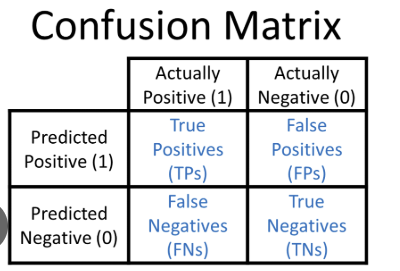

The confusion matrix displays number of true positive(TP), true negative(TN), false positive(FP) and false negative(FN).

TP: The values that were actually true and correctly predicted as true.

TN: The values that were actually false and correctly predicted as false.

FP: The values that were actually false but predicted as true.

FN: The values that were actually true but predicted as false.

In [39]:
from numpy import mean
from numpy import std

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [40]:
from sklearn.metrics import classification_report

f1 = f1_score(y_test, pred_labels)
recall = recall_score(y_test, pred_labels)
precision = precision_score(y_test, pred_labels)

f1_avg = mean(f1_score(y_test, pred_labels, average=None))
recall_avg = mean(recall_score(y_test, pred_labels, average=None))
precision_avg = mean(precision_score(y_test, pred_labels, average=None))

f1_sd = std(f1_score(y_test, pred_labels, average=None))
recall_sd = std(recall_score(y_test, pred_labels, average=None))
precision_sd = std(precision_score(y_test, pred_labels, average=None))

print('\nf1:\t\t',f1)
print('recall\t\t',recall)
print('precision\t',precision)

print('\nf1_avg:\t\t',f1_avg)
print('recall_avg\t',recall_avg)
print('precision_avg\t',precision_avg)

print('\nf1_sd:\t\t',f1_sd)
print('recall_sd\t',recall_sd)
print('precision_sd\t',precision_sd)

print('\n',classification_report(y_test, pred_labels))


f1:		 0.3225806451612903
recall		 0.23809523809523808
precision	 0.5

f1_avg:		 0.5249266862170088
recall_avg	 0.5432900432900433
precision_avg	 0.5681818181818181

f1_sd:		 0.2023460410557185
recall_sd	 0.3051948051948052
precision_sd	 0.06818181818181818

               precision    recall  f1-score   support

           0       0.64      0.85      0.73        33
           1       0.50      0.24      0.32        21

    accuracy                           0.61        54
   macro avg       0.57      0.54      0.52        54
weighted avg       0.58      0.61      0.57        54



Accuracy: how close the predicted value is to the actual standard value

Precision: repeatability of the predicted values(basically consistency)

Recall: ratio of correct positive to total postive

F1-score: harmonic mean of precision and recall

# Task 2

## 1) Data retrieval and collection

In [ ]:
datas = pd.read_csv("Heart_Disease_Prediction.csv")
datas.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [45]:
#shape of dataset
print("Shape of dataset:",datas.shape)

#column names
print("Columns:\n", datas.columns.tolist())

Shape of dataset: (270, 14)
Columns:
 ['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']


In [48]:
#description of dataset
datas.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


## 2) Data cleaning

In [47]:
print(datas.isnull().sum())

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64


In [50]:
#ensure the target variable is binary
print(datas["Heart Disease"].unique())

<StringArray>
['Presence', 'Absence']
Length: 2, dtype: str


In [52]:
datas["Heart Disease"] = data["Heart Disease"].map({
    "Absence": 0,
    "Presence": 1
})

print(data["Heart Disease"].unique())

[1 0]


In [53]:
#verify data types
print(datas.dtypes)

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease              float64
dtype: object


## 3) Feature Design

In [54]:
a=datas.drop("Heart Disease", axis=1) #axis=0(rows) and axis=1(columns)
b= data['Heart Disease']

print(a.shape)
print(b.shape)

(270, 13)
(270,)


## 4) Algorithm selection

In [ ]:
from sklearn.linear_model import LogisticRegression

models=LogisticRegression(max_iter=1000) # model needed more iterations as it showed convergencewarning(failed to convert after 100 iterations)

## 5) Loss function selection

Log loss is selected as the loss function by default for logistic regression

## 6) Model Training

In [56]:
from sklearn.model_selection import train_test_split

a_train, a_test, b_train, b_test = train_test_split(
    a,
    b,
    test_size=0.2, #80% data in training and 20% data in testing
    random_state=42,
    shuffle=True # this is used to ensure the same split every time we run the code
)

print("a_train shape:", a_train.shape)
print("a_test shape:", a_test.shape)
print("b_train shape:", b_train.shape)
print("b_test shape:", b_test.shape)

a_train shape: (216, 13)
a_test shape: (54, 13)
b_train shape: (216,)
b_test shape: (54,)


In [72]:
#Train the logistic regression model

models.fit(a_train, b_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [73]:
print("Coefficient:", models.coef_)
print("Intercept:", models.intercept_)

Coefficient: [[-0.01419511  1.0505477   0.64666165  0.02327414  0.00502792 -0.66877911
   0.09320452 -0.01157461  0.67014662  0.47574815  0.44179883  0.83574765
   0.32726597]]
Intercept: [-8.37973131]


the model is trained using 13 features(excluding Cholesterol) so there are 13 coefficients

## 7) Model evaluation

In [75]:
predict_labels = models.predict(a_test)

In [76]:
from sklearn.metrics import confusion_matrix

cm1 = confusion_matrix(b_test, predict_labels)
print(cm1)

[[32  1]
 [ 3 18]]


In [77]:
from numpy import mean
from numpy import std

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [78]:
from sklearn.metrics import classification_report

f1 = f1_score(b_test, predict_labels)
recall = recall_score(b_test, predict_labels)
precision = precision_score(b_test, predict_labels)

f1_avg = mean(f1_score(b_test, predict_labels, average=None))
recall_avg = mean(recall_score(b_test, predict_labels, average=None))
precision_avg = mean(precision_score(b_test, predict_labels, average=None))

f1_sd = std(f1_score(b_test, predict_labels, average=None))
recall_sd = std(recall_score(b_test, predict_labels, average=None))
precision_sd = std(precision_score(b_test, predict_labels, average=None))

print('\nf1:\t\t',f1)
print('recall\t\t',recall)
print('precision\t',precision)

print('\nf1_avg:\t\t',f1_avg)
print('recall_avg\t',recall_avg)
print('precision_avg\t',precision_avg)

print('\nf1_sd:\t\t',f1_sd)
print('recall_sd\t',recall_sd)
print('precision_sd\t',precision_sd)

print('\n',classification_report(b_test, predict_labels))


f1:		 0.9
recall		 0.8571428571428571
precision	 0.9473684210526315

f1_avg:		 0.9205882352941177
recall_avg	 0.9134199134199135
precision_avg	 0.9308270676691729

f1_sd:		 0.02058823529411763
recall_sd	 0.056277056277056314
precision_sd	 0.016541353383458635

               precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54



## Comparison between task 1 and task 2

         Accuracy  Precision   Recall   F1-score

Task 1    0.61       0.50       0.24     0.32

Task 2    0.93       0.95       0.86     0.90


### Which model performs better and why?

Accuracy, precision recall and f1-score have shown an increment in task 2 in comparision to task 1. So, model from task 2 performs better

### How does adding more features affect accuracy and recall?

Task 2 has more features and the accuracy and recall both seem to have increased in task 2.

Accuracy= (tn+tp)/(tp+fp+fn+tn)

Recall= tp/(tp+fn)

Addition of multiple features help the model to learn more meaningful patterns due to which the accuracy and recall improve in task 2


### Tradeoff betn interpretability and performance

Interpretability is how easy a model is to understand

Performance is how accurate the model is

In task 1, there is a single feature from which the model is trained which makes it easier to interpret but looking at the performance, the accuracy of task 1 is comparatively lower than that of task 2

In task 2, there are multiple features to train the model which makes it harder to interpret and the accuracy of task 2 is comparatively higher than that of task 1

## Discussion

Logistic regression model was applied by following the ML pipeline. Through accuracy, precision,recall and f1-score, we can clearly see that the logistic regression with multiple features is much more reliable than than of the logistic regression with a single feature.

The model working with only a single feature is highly interpretable but not accurate while the opposite is what works when it comes to model working with multiple features

## Conclusion

With the completion of the assignment, the application of the logistic regression in the real world can be seen. In task 1, heart disease was predicted using only one parameter i.e. cholesterol. While in task 2, heart disease is predicted using multiple paramters.

The results show that task 2 is better. Also, cholesterol isn't the only factor that causes heart disease in real life. So, for practically also, the implication of task 2 seems much better